In [2]:
from google.colab import files
uploade=files.upload()

Saving customer_segmentation_better.csv to customer_segmentation_better.csv


In [4]:
import pandas as pd
import numpy as np
df=pd.read_csv("customer_segmentation_better.csv")

if running through github use the following code for creating df

In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/shreyadavv/Machine_Learning_Assignment-Shreya_Yadav/refs/heads/main/customer_segmentation_better.csv"
df = pd.read_csv(url)

#EDA for data unterstanding

In [5]:
df.info()
df.describe()
df.head()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      500 non-null    int64
 1   Age             500 non-null    int64
 2   AnnualIncome    500 non-null    int64
 3   SpendingScore   500 non-null    int64
 4   VisitsPerMonth  500 non-null    int64
 5   AvgOrderValue   500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


np.int64(0)

Standardizing Features

In [6]:
from sklearn.preprocessing import StandardScaler

features=df.drop("CustomerID", axis=1)

scaler=StandardScaler()
scaled_data=scaler.fit_transform(features)

Elbow Method and Silhouette Score

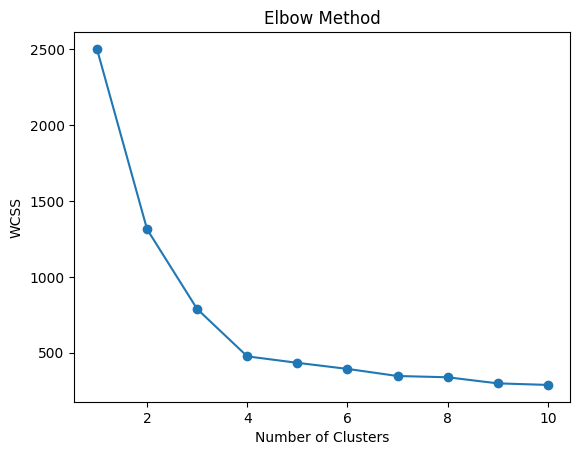

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]

for k in range(1,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  score=silhouette_score(scaled_data, kmeans.labels_)
  print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.4025341220790611
K=3, Silhouette Score=0.4502315416965807
K=4, Silhouette Score=0.49190768624438036
K=5, Silhouette Score=0.43228704251041605
K=6, Silhouette Score=0.37167921431787937
K=7, Silhouette Score=0.3394414587857232
K=8, Silhouette Score=0.3365509905427747
K=9, Silhouette Score=0.29201876437472346
K=10, Silhouette Score=0.29012714078045304


 K-Means clustering with k-3 as asked, we can change it to k-4 as well.

In [9]:
kmeans=KMeans(n_clusters=3,random_state=42)
df["Cluster"]=kmeans.fit_predict(scaled_data)

df.head()


,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue,Cluster
0,1,46,93599,1,3,246,2
1,2,59,99174,19,3,244,2
2,3,54,72454,2,2,219,2
3,4,50,81837,21,3,162,2
4,5,47,84039,12,2,118,2


Printing Cluster labels for customers

In [10]:
print(df[["CustomerID", "Cluster"]].head())

   CustomerID  Cluster
0           1        2
1           2        2
2           3        2
3           4        2
4           5        2


The centroids for each clusters

In [11]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features.columns)

print(centroids_df)

         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  42.040000  85519.160000      84.760000        7.328000     740.984000
1  31.119658  40562.294872      71.401709        5.572650     436.260684
2  51.049645  84092.007092      18.539007        2.177305     210.517730


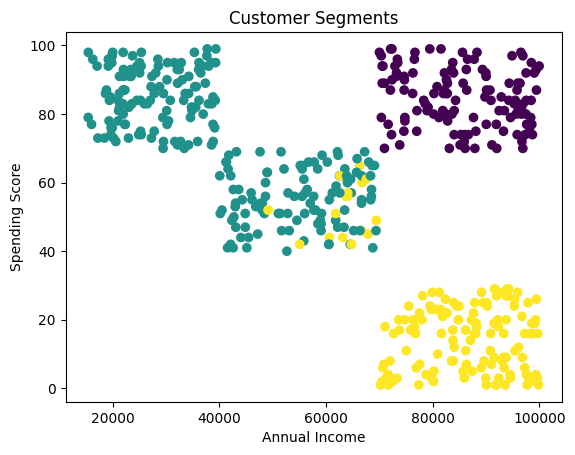

In [12]:
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

# Using PCA for just better visualization

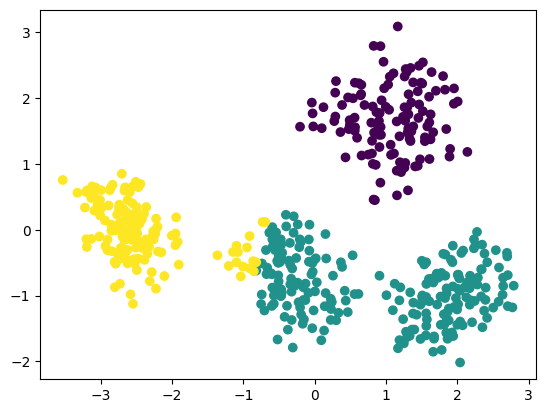

In [13]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(pca_data[:,0], pca_data[:,1],c=df['Cluster'])
plt.show()

# Interpretations
1.Why should you scale data before clustering?---Scaling ensures all features contribute equally,Otherwise features with larger scales can dominate.

2.What happens if features are on different scales?---variables with larger values dominate the distance calculation, leading to biased and incorrect clusters.

3.Would you include CustomerID in clustering?---no,because it is just an identifier and does not carry meaningful information.

4.How do you decide the optimal number of clusters(k)?---Elbow Method and Silhouette Score

5.Explain Elbow Method and Silhouette Score.---The Elbow Method identifies the point where adding more clusters does not significantly reduce WCSS. This point is chosen as the optimal number of clusters and Silhouette Score measures how similar a data point is to its own cluster compared to other clusters. Higher values indicate better clustering.

